In [25]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import mesa
import networkx as nx
import matplotlib.pyplot as plt
import random
from agents import Walker, ChargingStation
from models import MyModel
from matplotlib.animation import FuncAnimation


print(mesa.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
3.3.1


In [26]:

sizes = [15, 20, 12, 18]  # 4 communities

p = [
    [0.7,  0.05, 0.02, 0.15],
    [0.05, 0.6,  0.08, 0.03],
    [0.02, 0.08, 0.75, 0.10],
    [0.15, 0.03, 0.10, 0.5 ],
]

G = nx.stochastic_block_model(sizes, p, seed=42)

In [27]:
nx.set_node_attributes(G, 1, 'capacity')  # everyone gets 3
G.nodes[20]['capacity'] = 1               # charging station node gets 1
print(G.nodes[20])
print(G.nodes[0])

{'block': 1, 'capacity': 1}
{'block': 0, 'capacity': 1}


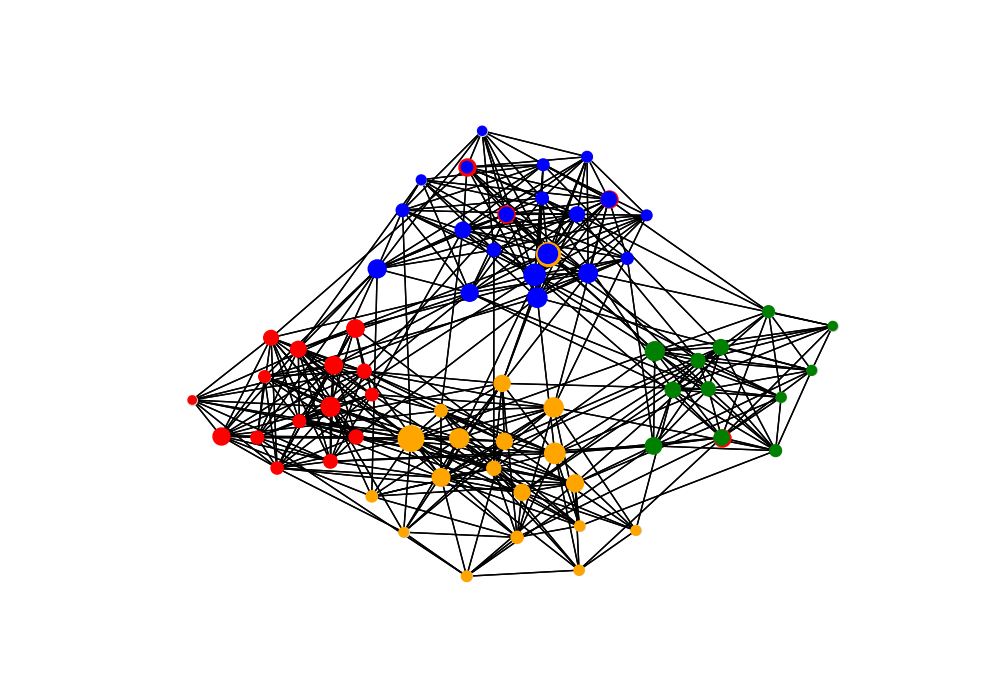

In [28]:

betweenness = nx.betweenness_centrality(G)
colors = ['red', 'blue', 'green', 'orange']
node_colors = [colors[G.nodes[n]['block']] for n in G.nodes()]
node_sizes = [betweenness[n] * 5000 + 30 for n in G.nodes()]

pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, node_color=node_colors, node_size=node_sizes)
plt.show()

In [29]:
print(list(G.neighbors(0)))

[1, 2, 3, 4, 6, 8, 9, 10, 11, 12, 13, 14, 64, 47, 49, 57]


In [30]:
betweenness = nx.betweenness_centrality(G)
print(sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5])

[(57, 0.06135271265108662), (18, 0.04070523626609954), (60, 0.03660101304531671), (17, 0.03294218314067971), (20, 0.03206153389913011)]


In [31]:
for node, score in [(57, 0.061), (18, 0.040), (60, 0.036), (17, 0.032), (20, 0.032)]:
    print(f"Node {node} → Block {G.nodes[node]['block']}")

Node 57 → Block 3
Node 18 → Block 1
Node 60 → Block 3
Node 17 → Block 1
Node 20 → Block 1


frame 0
Agent 1 wandering to 18
Agent 2 wandering to 40
Agent 3 wandering to 23
Agent 4 wandering to 36
Agent 4 stopped from wandering to 36
Agent 5 wandering to 56
Agent 6 wandering to 30
Agent 7 wandering to 24
Agent 8 wandering to 44
Agent 9 wandering to 7
Agent 10 wandering to 32
Station sees 0 walkers
frame 0
Agent 1 wandering to 19
Agent 2 wandering to 43
Agent 3 wandering to 30
Agent 3 stopped from wandering to 30
Agent 4 wandering to 37
Agent 5 wandering to 49
Agent 6 wandering to 18
Agent 7 wandering to 29
Agent 8 wandering to 46
Agent 9 wandering to 57
Agent 10 wandering to 34
Station sees 0 walkers
frame 1
Agent 1 wandering to 29
Agent 1 stopped from wandering to 29
Agent 2 wandering to 35
Agent 3 wandering to 30
Agent 4 wandering to 45
Agent 5 wandering to 62
Agent 6 wandering to 33
Agent 7 wandering to 32
Agent 8 wandering to 38
Agent 9 wandering to 9
Agent 10 wandering to 15
Station sees 0 walkers
frame 2
Agent 1 wandering to 18
Agent 2 wandering to 44
Agent 3 wandering t

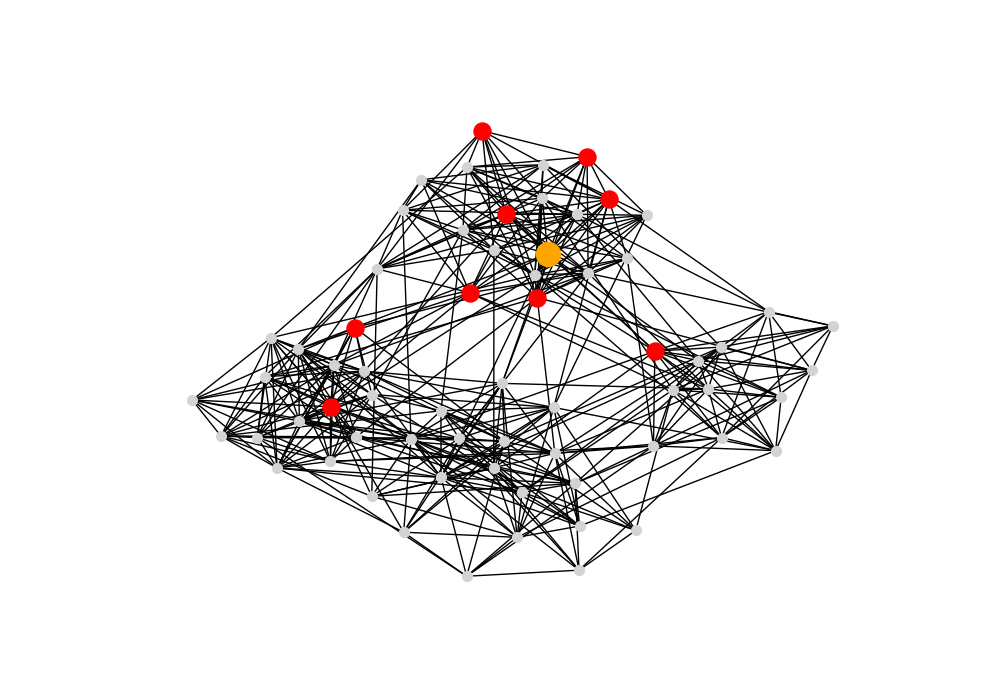

In [32]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

model = MyModel(G)
fig, ax = plt.subplots(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)

def update(frame):
        
    print(f"frame {frame}")
    ax.clear()
    model.step()
    
    nx.draw(G, pos, ax=ax, node_color='lightgray', node_size=50)
    
    walker_positions = [a.pos for a in model.agents_by_type[Walker]]
    nx.draw_networkx_nodes(G, pos, nodelist=walker_positions,
                           node_color='red', node_size=150, ax=ax)
    
    station = list(model.agents_by_type[ChargingStation])[0]
    occupants = [a for a in model.grid.get_cell_list_contents([station.pos])
                 if isinstance(a, Walker)]
    station_color = 'orange' if len(occupants) > 0 else 'blue'
    nx.draw_networkx_nodes(G, pos, nodelist=[station.pos],
                           node_color=station_color, node_size=300, ax=ax)

ani = FuncAnimation(fig, update, frames=30, interval=500)
ani.save("simulation.mp4", writer='ffmpeg', fps=2)
print("saved!")

pos = nx.spring_layout(G, seed=42)  # fixed layout so it doesn't change each step

plt.figure(figsize=(10, 7))
nx.draw(G, pos, node_color='darkgreen', node_size=50)

# Draw walker positions
walker_positions = [agent.pos for agent in model.agents_by_type[Walker]]
nx.draw_networkx_nodes(G, pos, nodelist=walker_positions, node_color='red', node_size=150)

# Draw station
station_pos = [agent.pos for agent in model.agents_by_type[ChargingStation]]
station = list(model.agents_by_type[ChargingStation])[0]
occupants = [a for a in model.grid.get_cell_list_contents([station.pos]) if isinstance(a, Walker)]
station_color = 'orange' if len(occupants) > 0 else 'blue'

nx.draw_networkx_nodes(G, pos, nodelist=station_pos, node_color=station_color, node_size=300)

plt.show()